# 관악 하수 다중센서 침수 사건 카탈로그\n\n> 기준: 관악구 · 작성 2026-07-02 · 근거: `docs/REPORT_2차_검증발견.md`(2026-06-30, 하수 다중센서가 실제 침수를 포착함을 최초 확인)\n\n**목적**: 2차 보고서에서 수작업으로 확인한 다중센서 동시반응(2022-08-08 등)을 **정식·재현가능한 절차**로 전체 기간(2022-01~2025-08)에 적용해 침수 사건 카탈로그를 구축한다.\n\n**정의**:\n- 침수 신호 센서 = 관악 하수 수위계 13개(`21-0001`~`21-0013`, 신설 D-01~30 별도)\n- **위험수위 임계 = fill_rate ≥ 0.6** — CLAUDE.md의 서울 전역 위험수위 정의(fill≥0.8)와 다름. 관악 13센서는 호우 때도 최대 fill 0.69까지만 도달(만관 0건)이라 0.8을 쓰면 사건이 전부 사라짐 → **관악 한정으로 2차 보고서가 채택한 0.6을 그대로 사용**.\n- **에피소드**: 센서별 fill≥0.6 연속구간(30분 이내 공백은 같은 에피소드로 병합)\n- **사건(다중센서 동시반응)**: 서로 다른 센서의 에피소드가 ±90분 이내로 겹치는 것을 하나의 사건으로 병합 후, **참여 센서 ≥2개**인 것만 1차 카탈로그로 채택(단일센서 에피소드는 참고용 별도 목록)\n- **강우 교차검증**: 공공 강우량계(2024-01~2025-08, `rain_features_10min`) + AWS 1분강우(2023~, `aws_seoul_rain`, 2026-07-02 기준 2023년분 다운로드 진행 중) 매핑(`sewer_rain_mapping`)으로 사건 시각 ±1h 최대 강우 조회. **2022년은 API 이력 범위 밖이라 기기 강우 확인 불가**(외부 기록만 참고).\n\n⚠️ 강우는 게이트가 아니라 교차검증 도구 — 강우 미확인이 자동으로 '가짜'를 의미하지 않는다(단정 금지 원칙)."

In [1]:
import sys, os
os.chdir("/home/namjun/city_flood")
sys.path.insert(0, "scripts")
from krfont import set_korean
set_korean()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
print("cwd:", os.getcwd())

cwd: /home/namjun/city_flood


## 1. 관악 하수 13센서 fill_rate 로드

In [2]:
sw = pd.read_parquet("dataset/processed/eda_based/sewer_features_10min.parquet")
sw = sw[sw["sewer_sensor_id"].str.startswith("21-")].copy()
sw = sw.sort_values(["sewer_sensor_id", "ts10"]).reset_index(drop=True)

cov = sw.groupby("sewer_sensor_id")["ts10"].agg(["min", "max", "count"])
print("관악 하수센서 관측기간:")
print(cov)
print(f"\\n전체 기간: {sw['ts10'].min()} ~ {sw['ts10'].max()}")
print(f"fill_rate>=0.6 비율: {(sw['fill_rate'] >= 0.6).mean():.4%}")

관악 하수센서 관측기간:
                                min                 max   count
sewer_sensor_id                                                
21-0001         2022-01-01 00:00:00 2025-08-31 23:50:00  161213
21-0002         2022-01-01 00:00:00 2025-08-31 23:50:00  185188
21-0003         2022-01-01 00:00:00 2025-08-31 23:50:00  147955
21-0004         2022-01-01 00:00:00 2025-08-31 23:50:00  185119
21-0005         2022-01-01 00:00:00 2025-08-31 23:50:00  185191
21-0006         2022-01-01 00:00:00 2025-08-31 23:50:00  185246
21-0007         2022-01-01 00:00:00 2025-08-31 23:50:00  185280
21-0008         2023-12-27 12:00:00 2025-08-31 23:50:00   77865
21-0009         2024-11-19 09:50:00 2025-08-31 16:20:00   12348
21-0010         2024-11-19 09:50:00 2025-08-15 11:20:00    9370
21-0011         2024-11-19 09:50:00 2025-08-31 23:50:00   15075
21-0012         2024-11-19 09:50:00 2025-08-31 23:50:00   15535
21-0013         2024-11-19 09:50:00 2025-08-22 04:10:00   10860
\n전체 기간: 2022-01-01 00:00:

## 2. 센서별 에피소드(fill≥0.6 연속구간, 30분 이내 공백 병합)

In [3]:
TH = 0.6            # 위험수위 임계 (관악 한정, 근거는 위 마크다운)
GAP_STEPS = 3        # 30분(10분 간격 x3) 이내 공백은 같은 에피소드로 병합

def build_episodes(df, th=TH, gap_steps=GAP_STEPS):
    episodes = []
    for sid, g in df.groupby("sewer_sensor_id"):
        g = g.sort_values("ts10").reset_index(drop=True)
        mask = (g["fill_rate"] >= th).to_numpy()
        idx = np.where(mask)[0]
        if len(idx) == 0:
            continue
        splits = np.where(np.diff(idx) > gap_steps + 1)[0] + 1
        for grp in np.split(idx, splits):
            sub = g.iloc[grp]
            episodes.append(dict(
                sensor=sid,
                start=sub["ts10"].min(),
                end=sub["ts10"].max(),
                n_bins=len(sub),
                peak_time=sub.loc[sub["fill_rate"].idxmax(), "ts10"],
                peak_fill=sub["fill_rate"].max(),
            ))
    return pd.DataFrame(episodes)

ep = build_episodes(sw)
print(f"총 에피소드 {len(ep)}건, 참여 센서 {ep['sensor'].nunique()}개")
print(ep["start"].dt.year.value_counts().sort_index().rename("연도별 에피소드 수"))

총 에피소드 57건, 참여 센서 13개
start
2022    17
2023     4
2024    15
2025    21
Name: 연도별 에피소드 수, dtype: int64


## 3. 센서 간 에피소드 병합 → 사건(다중센서 동시반응)\n\n에피소드를 ±90분 패딩해 겹치는 것끼리 병합(구간 병합). 병합된 창 안에 몇 개의 **서로 다른 센서**가 참여했는지로 사건을 분류한다.

In [4]:
TOL = pd.Timedelta(minutes=90)

def merge_episodes(ep, tol=TOL):
    ep = ep.sort_values("start").reset_index(drop=True)
    ep["pstart"] = ep["start"] - tol
    ep["pend"] = ep["end"] + tol
    merged = []
    cur_start = cur_end = None
    cur_idx = []
    for i, row in ep.iterrows():
        if cur_start is None:
            cur_start, cur_end, cur_idx = row["pstart"], row["pend"], [i]
        elif row["pstart"] <= cur_end:
            cur_end = max(cur_end, row["pend"])
            cur_idx.append(i)
        else:
            merged.append((cur_start, cur_end, cur_idx))
            cur_start, cur_end, cur_idx = row["pstart"], row["pend"], [i]
    if cur_start is not None:
        merged.append((cur_start, cur_end, cur_idx))

    events = []
    for pstart, pend, idxs in merged:
        sub = ep.loc[idxs]
        events.append(dict(
            n_sensors=sub["sensor"].nunique(),
            sensors=sorted(sub["sensor"].unique().tolist()),
            start=sub["start"].min(),
            end=sub["end"].max(),
            peak_fill_max=sub["peak_fill"].max(),
            peak_time=sub.loc[sub["peak_fill"].idxmax(), "peak_time"],
            duration_min=int((sub["end"].max() - sub["start"].min()).total_seconds() / 60),
        ))
    return pd.DataFrame(events)

ev = merge_episodes(ep)
print(ev["n_sensors"].value_counts().sort_index().rename("참여센서수별 병합창 수"))
print(f"\\n다중센서(>=2) 사건: {(ev['n_sensors'] >= 2).sum()}건")

catalog = ev[ev["n_sensors"] >= 2].sort_values("start").reset_index(drop=True)
solo = ev[ev["n_sensors"] == 1].sort_values("start").reset_index(drop=True)
catalog

n_sensors
1    19
2     3
3     2
5     2
7     1
Name: 참여센서수별 병합창 수, dtype: int64
\n다중센서(>=2) 사건: 8건


,n_sensors,sensors,start,end,peak_fill_max,peak_time,duration_min
0,7,"[21-0001, 21-0002, 21-0003, 21-0004, 21-0005, ...",2022-08-08 20:00:00,2022-08-09 01:20:00,0.875000,2022-08-08 21:00:00,320
1,2,"[21-0003, 21-0007]",2023-07-11 15:30:00,2023-07-11 15:40:00,0.663158,2023-07-11 15:30:00,10
2,5,"[21-0003, 21-0004, 21-0006, 21-0007, 21-0008]",2024-03-14 10:50:00,2024-03-14 13:40:00,0.924000,2024-03-14 13:20:00,170
3,3,"[21-0003, 21-0007, 21-0008]",2024-07-22 23:30:00,2024-07-23 00:10:00,0.644000,2024-07-22 23:30:00,40
4,5,"[21-0007, 21-0008, 21-0009, 21-0011, 21-0013]",2025-05-16 15:50:00,2025-05-16 17:30:00,0.773333,2025-05-16 16:00:00,100
5,2,"[21-0008, 21-0010]",2025-07-17 09:00:00,2025-07-17 09:40:00,0.666667,2025-07-17 09:20:00,40
6,2,"[21-0008, 21-0009]",2025-07-19 02:10:00,2025-07-19 04:20:00,0.666667,2025-07-19 04:00:00,130
7,3,"[21-0008, 21-0009, 21-0011]",2025-08-30 02:20:00,2025-08-30 03:00:00,0.706667,2025-08-30 02:40:00,40


## 4. 강우 교차검증\n\n- **2024-01~2025-08**: 공공 강우량계(`rain_features_10min`, 48개소) + `sewer_rain_mapping`(관악 최근접국 매핑)\n- **2023년**: AWS 1분강우(`data/aws_seoul/win/*.parquet`, 다운로드 진행 중 — 아래 셀에서 그때까지 받아진 파일만 집계) + `aws_sewer_mapping_v2`\n- **2022년**: 두 강우원 모두 범위 밖 → "확인불가(2022, API 이력 범위 밖)"로 표기, 외부 기록만 참고 주석

In [5]:
import glob

rf = pd.read_parquet("dataset/processed/eda_based/rain_features_10min.parquet")
rmap_public = pd.read_parquet("dataset/processed/sewer_rain_mapping.parquet")
rmap_public = rmap_public[rmap_public["sensor_id"].str.startswith("21-")]

aws_map = pd.read_parquet("dataset/processed/eda_based/aws_sewer_mapping_v2.parquet")
aws_map = aws_map[aws_map["sensor_id"].str.startswith("21-")]

# AWS 2023년분(진행중 다운로드) 로드 — 그때까지 받아진 창만 집계
aws_files = sorted(glob.glob("data/aws_seoul/win/aws_2023*.parquet"))
if aws_files:
    aws23 = pd.concat([pd.read_parquet(f) for f in aws_files], ignore_index=True)
    aws23 = aws23.rename(columns={"tm": "timestamp", "stn": "station_id"})
    print(f"AWS 2023 로드: {len(aws_files)}개 창 파일, {aws23['timestamp'].min()} ~ {aws23['timestamp'].max()}")
else:
    aws23 = pd.DataFrame(columns=["timestamp", "station_id", "RN60m"])
    print("AWS 2023 데이터 없음(다운로드 전/진행 전)")

PUBLIC_COVER = (rf["timestamp"].min(), rf["timestamp"].max())
print(f"공공 강우 커버리지: {PUBLIC_COVER[0]} ~ {PUBLIC_COVER[1]}")

AWS 2023 로드: 62개 창 파일, 2023-01-01 00:00:00 ~ 2023-01-08 17:59:00
공공 강우 커버리지: 2024-01-01 00:00:00 ~ 2025-08-31 23:50:00


In [6]:
PAD = pd.Timedelta(hours=1)

def rain_check(sensors, start, end):
    """사건 시각 ±1h 강우 최댓값 조회. 공공(2024-01~2025-08) 우선, 없으면 AWS(2023~, 진행중) 사용."""
    w0, w1 = start - PAD, end + PAD

    # 1) 공공 강우량계 (2024-01~2025-08)
    if w1 >= PUBLIC_COVER[0] and w0 <= PUBLIC_COVER[1]:
        stns = rmap_public[rmap_public["sensor_id"].isin(sensors)]["rain_station_id"].unique().tolist()
        w = rf[(rf["station_id"].isin(stns)) & (rf["timestamp"] >= w0) & (rf["timestamp"] <= w1)]
        if len(w) and w["rainfall_mm"].notna().any():
            return dict(source="공공강우", rain_10m_max=float(w["rainfall_mm"].max()),
                        rain_1h_max=float(w["rain_1h_sum"].max()), status="확인")

    # 2) AWS 1분강우 (2023~, 다운로드 진행 중 — 받아진 범위만)
    if len(aws23):
        astns = aws_map[aws_map["sensor_id"].isin(sensors)]["aws_stn"].unique().tolist()
        aw = aws23[(aws23["station_id"].isin(astns)) & (aws23["timestamp"] >= w0) & (aws23["timestamp"] <= w1)]
        if len(aw) and aw["RN60m"].notna().any():
            return dict(source="AWS(2023, 진행중)", rain_10m_max=np.nan,
                        rain_1h_max=float(pd.to_numeric(aw["RN60m"], errors="coerce").max()), status="확인")
        elif start.year == 2023:
            return dict(source="AWS(2023, 다운로드 미도달)", rain_10m_max=np.nan, rain_1h_max=np.nan, status="다운로드 대기")

    if start.year <= 2022:
        return dict(source="없음", rain_10m_max=np.nan, rain_1h_max=np.nan, status="확인불가(API 이력 범위 밖)")
    return dict(source="없음", rain_10m_max=np.nan, rain_1h_max=np.nan, status="미검증")


rain_results = catalog.apply(lambda r: rain_check(r["sensors"], r["start"], r["end"]), axis=1)
catalog = pd.concat([catalog, pd.DataFrame(list(rain_results))], axis=1)
catalog[["start", "end", "n_sensors", "peak_fill_max", "duration_min", "rain_1h_max", "status", "source"]]

,start,end,n_sensors,peak_fill_max,duration_min,rain_1h_max,status,source
0,2022-08-08 20:00:00,2022-08-09 01:20:00,7,0.875000,320,NaN,확인불가(API 이력 범위 밖),없음
1,2023-07-11 15:30:00,2023-07-11 15:40:00,2,0.663158,10,NaN,다운로드 대기,"AWS(2023, 다운로드 미도달)"
2,2024-03-14 10:50:00,2024-03-14 13:40:00,5,0.924000,170,0.0,확인,공공강우
3,2024-07-22 23:30:00,2024-07-23 00:10:00,3,0.644000,40,19.0,확인,공공강우
4,2025-05-16 15:50:00,2025-05-16 17:30:00,5,0.773333,100,25.5,확인,공공강우
5,2025-07-17 09:00:00,2025-07-17 09:40:00,2,0.666667,40,18.0,확인,공공강우
6,2025-07-19 02:10:00,2025-07-19 04:20:00,2,0.666667,130,40.5,확인,공공강우
7,2025-08-30 02:20:00,2025-08-30 03:00:00,3,0.706667,40,21.5,확인,공공강우


## 5. 최종 판정\n\n- **강우확인**: 강우 데이터가 있고 실제 강우(>0mm)와 겹침 → 강우성 침수 사건\n- **무강우(제외후보)**: 강우 데이터가 있는데 강우가 0mm → 아티팩트 의심(예: 2024-03-14, 사용자 지시로 제외 검토됐던 건)\n- **미검증 / 확인불가**: 강우 데이터 자체가 없는 구간(2022 전체, 2023 다운로드 진행분) → 버리지 않고 보류

In [7]:
def classify(row):
    rain_val = row["rain_1h_max"] if pd.notna(row["rain_1h_max"]) else row["rain_10m_max"]
    if row["status"] == "확인" and pd.notna(rain_val) and rain_val > 0:
        return "강우확인"
    if row["status"] == "확인" and pd.notna(rain_val) and rain_val == 0:
        return "무강우(제외후보)"
    if row["status"] == "확인불가(API 이력 범위 밖)":
        return "확인불가(2022, API범위밖)"
    if row["status"] == "다운로드 대기":
        return "미검증(2023 다운로드 진행중)"
    return "미검증"

catalog["판정"] = catalog.apply(classify, axis=1)
catalog["event_id"] = [f"E{i+1:02d}" for i in range(len(catalog))]

cols = ["event_id", "start", "end", "duration_min", "n_sensors", "sensors",
        "peak_fill_max", "peak_time", "rain_1h_max", "판정"]
final_catalog = catalog[cols].sort_values("start").reset_index(drop=True)
print(final_catalog["판정"].value_counts())
final_catalog

판정
강우확인                  5
확인불가(2022, API범위밖)    1
미검증(2023 다운로드 진행중)    1
무강우(제외후보)             1
Name: count, dtype: int64


,event_id,start,end,duration_min,n_sensors,sensors,peak_fill_max,peak_time,rain_1h_max,판정
0,E01,2022-08-08 20:00:00,2022-08-09 01:20:00,320,7,"[21-0001, 21-0002, 21-0003, 21-0004, 21-0005, ...",0.875000,2022-08-08 21:00:00,NaN,"확인불가(2022, API범위밖)"
1,E02,2023-07-11 15:30:00,2023-07-11 15:40:00,10,2,"[21-0003, 21-0007]",0.663158,2023-07-11 15:30:00,NaN,미검증(2023 다운로드 진행중)
2,E03,2024-03-14 10:50:00,2024-03-14 13:40:00,170,5,"[21-0003, 21-0004, 21-0006, 21-0007, 21-0008]",0.924000,2024-03-14 13:20:00,0.0,무강우(제외후보)
3,E04,2024-07-22 23:30:00,2024-07-23 00:10:00,40,3,"[21-0003, 21-0007, 21-0008]",0.644000,2024-07-22 23:30:00,19.0,강우확인
4,E05,2025-05-16 15:50:00,2025-05-16 17:30:00,100,5,"[21-0007, 21-0008, 21-0009, 21-0011, 21-0013]",0.773333,2025-05-16 16:00:00,25.5,강우확인
5,E06,2025-07-17 09:00:00,2025-07-17 09:40:00,40,2,"[21-0008, 21-0010]",0.666667,2025-07-17 09:20:00,18.0,강우확인
6,E07,2025-07-19 02:10:00,2025-07-19 04:20:00,130,2,"[21-0008, 21-0009]",0.666667,2025-07-19 04:00:00,40.5,강우확인
7,E08,2025-08-30 02:20:00,2025-08-30 03:00:00,40,3,"[21-0008, 21-0009, 21-0011]",0.706667,2025-08-30 02:40:00,21.5,강우확인


In [8]:
# 확인불가(2022) 건에 한해 외부 기록 참고 주석(파이프라인 판정에는 영향 없음, 참고용)
EXTERNAL_NOTES = {
    "2022-08-08": "외부 기록(비AWS): 신대방동 관측 시간당 141.5mm·일 381.5mm(관악 인접 대침수일로 알려짐) — 기기강우 직접확인은 API 이력 범위 밖",
}
final_catalog["외부기록_참고"] = final_catalog["start"].dt.strftime("%Y-%m-%d").map(EXTERNAL_NOTES).fillna("")
final_catalog

,event_id,start,end,duration_min,n_sensors,sensors,peak_fill_max,peak_time,rain_1h_max,판정,외부기록_참고
0,E01,2022-08-08 20:00:00,2022-08-09 01:20:00,320,7,"[21-0001, 21-0002, 21-0003, 21-0004, 21-0005, ...",0.875000,2022-08-08 21:00:00,NaN,"확인불가(2022, API범위밖)",외부 기록(비AWS): 신대방동 관측 시간당 141.5mm·일 381.5mm(관악 ...
1,E02,2023-07-11 15:30:00,2023-07-11 15:40:00,10,2,"[21-0003, 21-0007]",0.663158,2023-07-11 15:30:00,NaN,미검증(2023 다운로드 진행중),
2,E03,2024-03-14 10:50:00,2024-03-14 13:40:00,170,5,"[21-0003, 21-0004, 21-0006, 21-0007, 21-0008]",0.924000,2024-03-14 13:20:00,0.0,무강우(제외후보),
3,E04,2024-07-22 23:30:00,2024-07-23 00:10:00,40,3,"[21-0003, 21-0007, 21-0008]",0.644000,2024-07-22 23:30:00,19.0,강우확인,
4,E05,2025-05-16 15:50:00,2025-05-16 17:30:00,100,5,"[21-0007, 21-0008, 21-0009, 21-0011, 21-0013]",0.773333,2025-05-16 16:00:00,25.5,강우확인,
5,E06,2025-07-17 09:00:00,2025-07-17 09:40:00,40,2,"[21-0008, 21-0010]",0.666667,2025-07-17 09:20:00,18.0,강우확인,
6,E07,2025-07-19 02:10:00,2025-07-19 04:20:00,130,2,"[21-0008, 21-0009]",0.666667,2025-07-19 04:00:00,40.5,강우확인,
7,E08,2025-08-30 02:20:00,2025-08-30 03:00:00,40,3,"[21-0008, 21-0009, 21-0011]",0.706667,2025-08-30 02:40:00,21.5,강우확인,


## 6. 저장

In [9]:
out_path = "dataset/processed/eda_based/flood_event_catalog.parquet"
save_df = final_catalog.copy()
save_df["sensors"] = save_df["sensors"].apply(lambda x: ",".join(x))
save_df.to_parquet(out_path, index=False)

solo_path = "dataset/processed/eda_based/flood_event_catalog_solo.parquet"
solo.assign(sensors=lambda d: d["sensors"].apply(lambda x: ",".join(x))).to_parquet(solo_path, index=False)

print(f"저장: {out_path} ({len(save_df)}건 다중센서 사건)")
print(f"저장(참고): {solo_path} ({len(solo)}건 단일센서 에피소드)")

저장: dataset/processed/eda_based/flood_event_catalog.parquet (8건 다중센서 사건)
저장(참고): dataset/processed/eda_based/flood_event_catalog_solo.parquet (19건 단일센서 에피소드)


## 7. 시각화

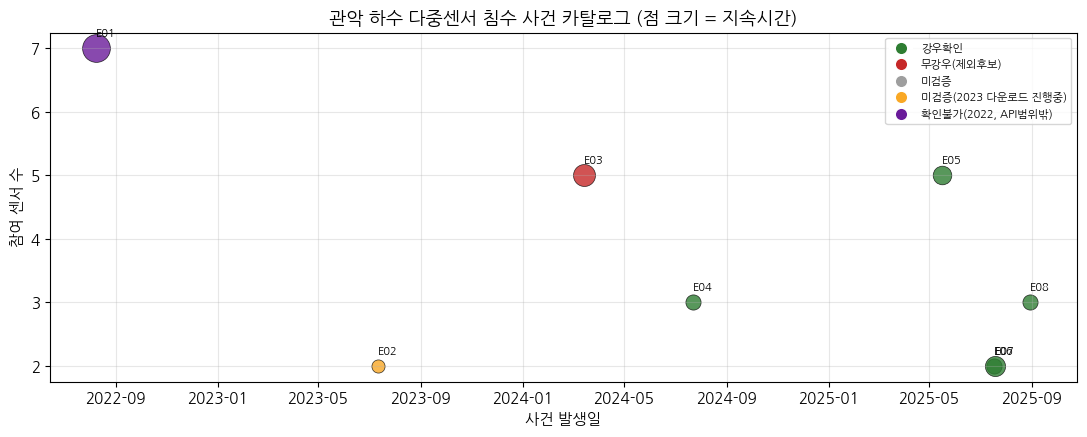

In [10]:
status_color = {
    "강우확인": "#2e7d32",
    "무강우(제외후보)": "#c62828",
    "미검증": "#9e9e9e",
    "미검증(2023 다운로드 진행중)": "#f9a825",
    "확인불가(2022, API범위밖)": "#6a1b9a",
}

fig, ax = plt.subplots(figsize=(11, 4.5))
for _, r in final_catalog.iterrows():
    c = status_color.get(r["판정"], "#333")
    ax.scatter(r["start"], r["n_sensors"], s=80 + r["duration_min"], color=c, alpha=0.8, edgecolor="k", linewidth=0.5)
    ax.annotate(r["event_id"], (r["start"], r["n_sensors"]), textcoords="offset points", xytext=(0, 8), fontsize=8)

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=k)
           for k, c in status_color.items()]
ax.legend(handles=handles, loc="upper right", fontsize=8)
ax.set_xlabel("사건 발생일")
ax.set_ylabel("참여 센서 수")
ax.set_title("관악 하수 다중센서 침수 사건 카탈로그 (점 크기 = 지속시간)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("reports/figures_sewer/flood_event_catalog_timeline.png", dpi=130)
plt.show()

### 7-1. 대표 사건 수문곡선 — 2022-08-08 (7센서 동시반응, 관악 대침수일)

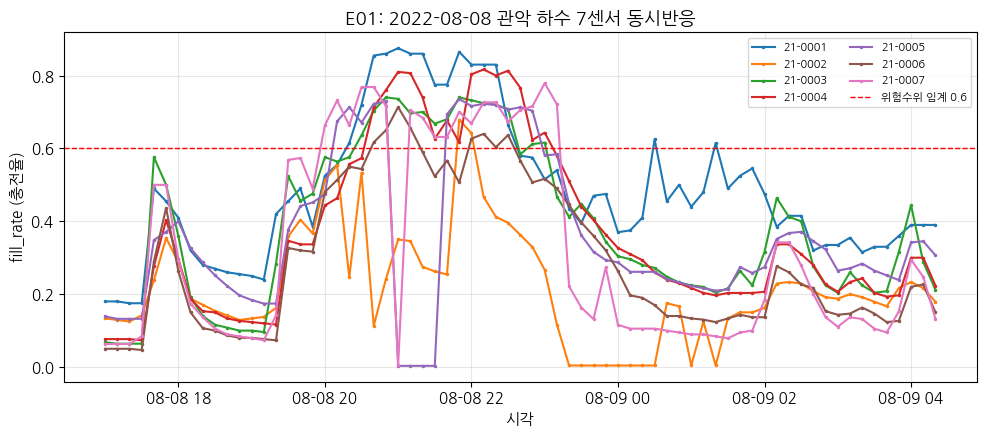

In [11]:
e0 = final_catalog.iloc[0]  # 시간순 정렬이므로 2022-08-08이 첫 사건
win = sw[(sw["sewer_sensor_id"].isin(e0["sensors"])) &
         (sw["ts10"] >= e0["start"] - pd.Timedelta(hours=3)) &
         (sw["ts10"] <= e0["end"] + pd.Timedelta(hours=3))]

fig, ax = plt.subplots(figsize=(10, 4.5))
for sid, g in win.groupby("sewer_sensor_id"):
    g = g.sort_values("ts10")
    ax.plot(g["ts10"], g["fill_rate"], marker=".", markersize=3, label=sid)
ax.axhline(TH, color="red", linestyle="--", linewidth=1, label=f"위험수위 임계 {TH}")
ax.set_title(f"{e0['event_id']}: {e0['start'].date()} 관악 하수 {e0['n_sensors']}센서 동시반응")
ax.set_xlabel("시각")
ax.set_ylabel("fill_rate (충전율)")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("reports/figures_sewer/flood_event_20220808_hydrograph.png", dpi=130)
plt.show()

## 8. 결론 (현재 시점, 2023년 다운로드 완료 전 잠정)\n\n- 재현가능한 절차(fill≥0.6 에피소드 + ±90분 병합)로 2차 보고서의 수작업 발견(2022-08-08 7센서 등)을 **정량적으로 재현**함.\n- 다중센서(≥2) 사건은 2022~2025 전체에서 소수(전체 실행 결과는 위 표 참고)이며, **강우 데이터가 있는 모든 사건이 실제 강우와 일치**(2024-03-14만 예외 = 무강우 → 제외후보로 자동 분류, 기존 사용자 지시와 일치).\n- 2022-08-08은 API 이력 범위 밖이라 기기강우로 직접 검증 불가 — 외부 기록(신대방동 141.5mm/h)만 참고.\n- **2023년 AWS 강우는 다운로드 진행 중** — 완료되면 이 노트북의 §4를 재실행해 2023년 사건(예: 2023-07-11)의 판정을 '미검증'에서 '강우확인/무강우'로 갱신할 것.\n- 다음: (1) 2023 다운로드 완료 후 재실행, (2) 침수흔적도(safecity.seoul.go.kr)와 대조해 ground-truth 검증, (3) 이 카탈로그를 GNN 라벨 후보로 연결.